# Day 2: Named Entity Recognition with Robert Louis Stevenson's Letters

In this notebook, we'll use pre-trained Named Entity Recognition (NER) models to extract people, places, organizations, and other entities from RLS's correspondence (1863-1890).

## Learning Goals
- Load and use pre-trained NLP models
- Process a large corpus systematically
- Create structured data from unstructured text
- Visualize extracted entities
- Evaluate model performance


## Section 1: Setup and Data Exploration

First, let's install the necessary libraries and explore our data.

In [ ]:
import random
import re
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from transformers import pipeline

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

warnings.filterwarnings('ignore')


In [88]:
# Load the metadata
metadata_path = '../data/letters_metadata.csv'
metadata = pd.read_csv(metadata_path)

print(f'Total letters in corpus: {len(metadata)}')
print('\nFirst few rows:')
metadata.head()


Total letters in corpus: 462

First few rows:


,addressee,date,month,day,year,file_name
0,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0,wikisource_vol1_ch1_letter1.txt
1,CHARLES BAXTER,APRIL 9 1872,APRIL,9.0,1872.0,wikisource_vol1_ch1_letter10.txt
2,MRS. THOMAS STEVENSON,JULY 25 1872,JULY,25.0,1872.0,wikisource_vol1_ch1_letter11.txt
3,MRS. THOMAS STEVENSON,JULY 29 1872,JULY,29.0,1872.0,wikisource_vol1_ch1_letter12.txt
4,MRS. THOMAS STEVENSON,AUGUST 2 1872,AUGUST,2.0,1872.0,wikisource_vol1_ch1_letter13.txt


In [89]:
# Read a sample letter
sample_file = '../data/letters/wikisource_vol1_ch3_letter14.txt'

with open(sample_file, encoding='utf-8') as file:
    sample_text = file.read()

print('Sample letter:')
print('=' * 80)
print(sample_text)
print('=' * 80)


Sample letter:
Letter: TO SIDNEY COLVIN

[EDINBURGH, AUGUST 1877.]

MY DEAR COLVIN, - I'm to be whipped away to-morrow to Penzance, where at the post-office a letter will find me glad and grateful. I am well, but somewhat tired out with overwork. I have only been home a fortnight this morning, and I have already written to the tune of forty-five CORNHILL pages and upwards. The most of it was only very laborious re-casting and re-modelling, it is true; but it took it out of me famously, all the same.
TEMPLE BAR appears to like my 'Villon,' so I may count on another market there in the future, I hope. At least, I am going to put it to the proof at once, and send another story, 'The Sire de Maletroit's Mousetrap': a true novel, in the old sense; all unities preserved moreover, if that's anything, and I believe with some little merits; not so CLEVER perhaps as the last, but sounder and more natural.
My 'Villon' is out this month; I should so much like to know what you think of it. Stephen 

## Section 2: Load a Pre-trained NER Model

We'll use the Hugging Face `transformers` library to load a pre-trained NER model. We're using `Davlan/bert-base-multilingual-cased-ner-hrl`, which recognizes:
- PER (Person)
- ORG (Organization)
- LOC (Location)


In [90]:
# Load the NER pipeline
print('Loading NER model... (this may take a minute the first time)')
ner_pipeline = pipeline(
    'ner',
    model='Davlan/bert-base-multilingual-cased-ner-hrl',
    aggregation_strategy='simple',  # approach used to merge consecutive tokens into entities
)


Loading NER model... (this may take a minute the first time)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Davlan/bert-base-multilingual-cased-ner-hrl
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [91]:
# Test the model on a simple sentence
test_text = 'Robert Louis Stevenson wrote to Sidney Colvin from Edinburgh in August 1877.'
results = ner_pipeline(test_text)

print('Test sentence:', test_text)
print('\nExtracted entities:')
for entity in results:
    print(f'  {entity["word"]:<25} | Type: {entity["entity_group"]:<6} | Score: {entity["score"]:.3f}')


Test sentence: Robert Louis Stevenson wrote to Sidney Colvin from Edinburgh in August 1877.

Extracted entities:
  Robert Louis Stevenson    | Type: PER    | Score: 1.000
  Sidney Colvin             | Type: PER    | Score: 1.000
  Edinburgh                 | Type: LOC    | Score: 1.000


In [92]:
# Now try the model on our sample letter
entities = ner_pipeline(sample_text)

print(f'Found {len(entities)} entities in the sample letter:\n')
for entity in entities:
    print(f'{entity["word"]:<30} | {entity["entity_group"]:<6} | {entity["score"]:.3f}')


Found 10 entities in the sample letter:

SI                             | LOC    | 0.498
##DNE                          | PER    | 0.620
COLVI                          | PER    | 0.846
EDINBURGH                      | LOC    | 0.996
COLVI                          | PER    | 0.711
Penzance                       | LOC    | 1.000
Stephen                        | PER    | 0.984
Stephen                        | PER    | 0.991
L                              | ORG    | 0.585
##OUIS STEVENSON               | LOC    | 0.674


Not great. `SIDNEY` is split into `SI` and `##DNE`, and `LOUIS STEVENSON` into `L` and `##OUIS STEVENSON`.

These are *WordPiece* tokenization artefacts caused by the ALL CAPS text in the letter.

The tokenizers in most BERT-based models are built from vocabularies of normally-cased text (news articles, web text). When the tokenizer encounters words in ALL CAPS those exact uppercase forms often aren't in the vocabulary, so the tokenizer falls back to splitting them into unusual subword pieces.

Normally `aggregation_strategy='simple'` would merge those `##` continuation tokens back together. But if the model assigns different entity labels, or confidence levels, to different subword pieces of the same word (which is likely since the model has never seen these odd all-caps splits during training), the aggregation can't merge them, so they surface as separate spurious entities.

The fix is to normalize the ALL CAPS text before running inference. We can do that with a simple function:

In [93]:
def normalize_caps(text):
    """Convert ALL-CAPS words to Title Case, preserving mixed-case words."""
    return re.sub(r'\b([A-Z]{2,})\b', lambda m: m.group(1).title(), text)


Let's try it now:

In [ ]:
# Now try the model on our sample letter
entities = ner_pipeline(normalize_caps(sample_text))

print(f'Found {len(entities)} entities in the sample letter:\n')
for entity in entities:
    print(f'{entity["word"]:<30} | {entity["entity_group"]:<6} | {entity["score"]:.3f}')


Found 9 entities in the sample letter:

Sidney Colvin                  | PER    | 0.989
Edinburgh                      | LOC    | 1.000
Penzance                       | LOC    | 0.999
Cornhill                       | ORG    | 0.998
Temple Bar                     | ORG    | 0.848
Clever                         | PER    | 0.984
Stephen                        | PER    | 0.999
Stephen                        | PER    | 0.998
Louis Stevenson                | PER    | 1.000


Great!

## Section 3: Process the Full Corpus

Now let's scale up! We'll process all 462 letters and collect the results.

In [95]:
def extract_entities_from_file(filepath):
    """Extract named entities from a single letter file.

    Returns: list of dicts with entity information
    """
    with open(filepath, encoding='utf-8') as file:
        text = file.read()

    # Run NER
    entities = ner_pipeline(normalize_caps(text))

    # Add the file name to each entity
    for entity in entities:
        entity['file_name'] = Path(filepath).name
        entity['text'] = entity.pop('word')  # Rename for clarity

    return entities

In [96]:
# Process all letters
letters_dir = Path('../data/letters')
all_entities = []

letter_files = sorted(letters_dir.glob('*.txt'))

print(f'Processing {len(letter_files)} letters...')
print('This will take a few minutes...\n')

for i, filepath in enumerate(letter_files):
    if (i + 1) % 50 == 0:
        print(f'  Processed {i + 1}/{len(letter_files)} letters...')

    try:
        entities = extract_entities_from_file(filepath)
        all_entities.extend(entities)
    except Exception as e:  # noqa: BLE001
        print(f'  Error processing {filepath.name}: {e}')

print(f'\nDone! Extracted {len(all_entities)} entities from {len(letter_files)} letters.')

Processing 462 letters...
This will take a few minutes...

  Processed 50/462 letters...
  Processed 100/462 letters...
  Processed 150/462 letters...
  Processed 200/462 letters...
  Processed 250/462 letters...
  Processed 300/462 letters...
  Processed 350/462 letters...
  Processed 400/462 letters...
  Processed 450/462 letters...

Done! Extracted 4978 entities from 462 letters.


In [97]:
# Convert to DataFrame for easier analysis
entities_df = pd.DataFrame(all_entities)

# Merge with metadata to get dates and addressees
entities_df = entities_df.merge(metadata, on='file_name', how='left')

print(f'Shape of results: {entities_df.shape}')
print(f'\nColumns: {list(entities_df.columns)}')
print('\nFirst few rows:')
entities_df.head(10)


Shape of results: (4978, 11)

Columns: ['entity_group', 'score', 'start', 'end', 'file_name', 'text', 'addressee', 'date', 'month', 'day', 'year']

First few rows:


,entity_group,score,start,end,file_name,text,addressee,date,month,day,year
0,ORG,0.942432,8,27,wikisource_vol1_ch1_letter1.txt,Spring Grove School,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0
1,PER,0.550253,53,57,wikisource_vol1_ch1_letter1.txt,Cher,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0
2,PER,0.758371,63,64,wikisource_vol1_ch1_letter1.txt,##n,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0
3,PER,0.993495,291,295,wikisource_vol1_ch1_letter1.txt,Faux,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0
4,LOC,0.995625,633,640,wikisource_vol1_ch1_letter1.txt,Mentone,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0
5,PER,0.984050,879,891,wikisource_vol1_ch1_letter1.txt,R. Stevenson,SPRING GROVE SCHOOL,NOVEMBER 12 1863,NOVEMBER,12.0,1863.0
6,PER,0.912143,11,35,wikisource_vol1_ch1_letter10.txt,Charles Baxter Dunblane,CHARLES BAXTER,APRIL 9 1872,APRIL,9.0,1872.0
7,PER,0.735237,70,76,wikisource_vol1_ch1_letter10.txt,Baxter,CHARLES BAXTER,APRIL 9 1872,APRIL,9.0,1872.0
8,ORG,0.996905,133,164,wikisource_vol1_ch1_letter10.txt,Standing Committee of the Spec.,CHARLES BAXTER,APRIL 9 1872,APRIL,9.0,1872.0
9,ORG,0.805749,308,313,wikisource_vol1_ch1_letter10.txt,Rural,CHARLES BAXTER,APRIL 9 1872,APRIL,9.0,1872.0


In [98]:
# Save results to CSV for future use
output_path = '../data/extracted_entities.csv'
entities_df.to_csv(output_path, index=False)

print(f'Results saved to {output_path}')


Results saved to ../data/extracted_entities.csv


## Section 4: Explore the Results

Now let's analyze what we extracted.

Entity types found:
entity_group
PER    2924
LOC    1815
ORG     239
Name: count, dtype: int64



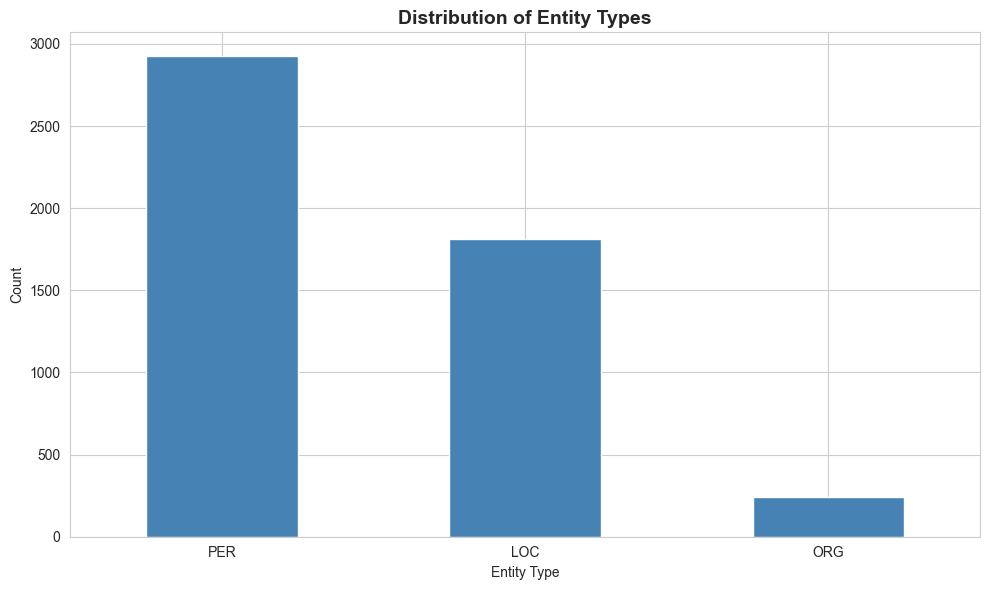

In [99]:
# Entity type distribution
entity_counts = entities_df['entity_group'].value_counts()

print('Entity types found:')
print(entity_counts)
print()

# Visualize
plt.figure(figsize=(10, 6))
entity_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Entity Types', fontsize=14, fontweight='bold')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Top 20 most mentioned locations:
text
Bournemouth        76
Samoa              68
Edinburgh          59
Vailima            59
England            33
Davos              31
Scotland           28
Honolulu           27
Sydney             27
San Francisco      26
London             22
Hyeres             22
Skerryvore         22
Saranac Lake       21
New York           20
Var                19
Monterey           18
States             18
California         16
Treasure Island    16
Name: count, dtype: int64



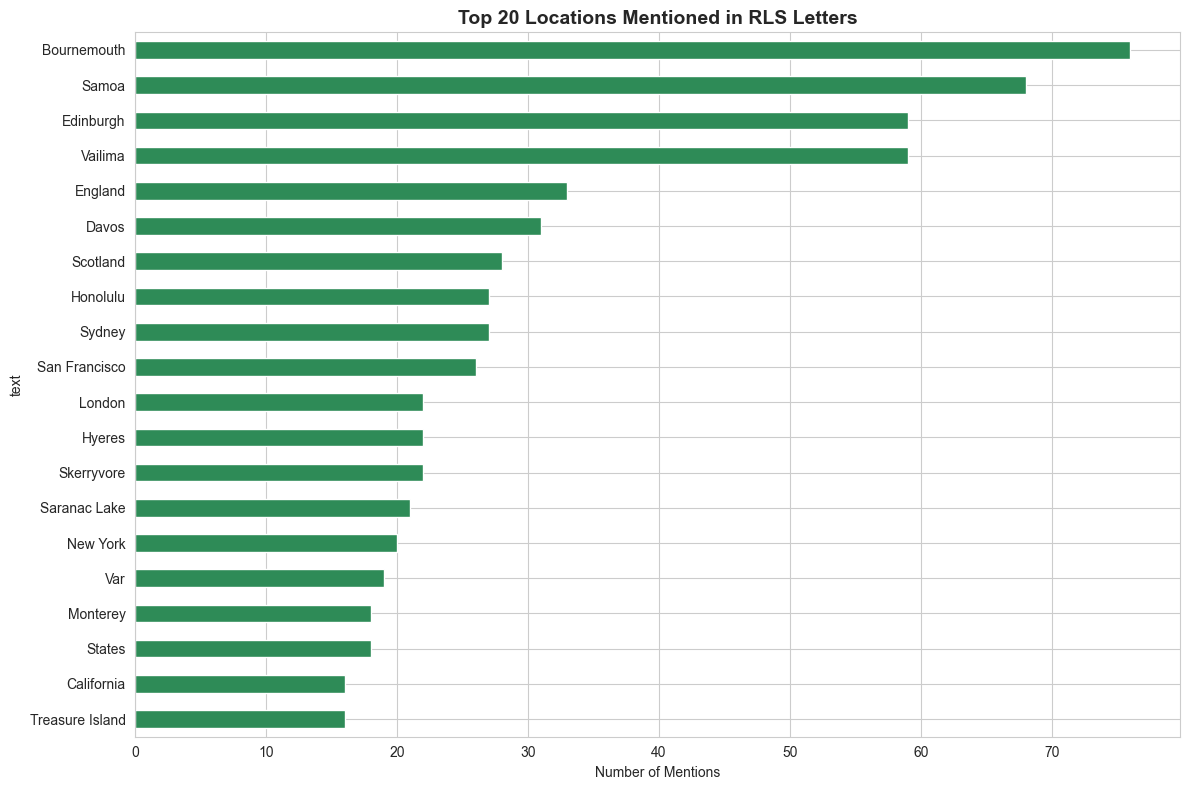

In [100]:
# Most frequently mentioned locations
locations = entities_df[entities_df['entity_group'] == 'LOC']['text'].value_counts().head(20)

print('Top 20 most mentioned locations:')
print(locations)
print()

# Visualize
plt.figure(figsize=(12, 8))
locations.plot(kind='barh', color='seagreen')
plt.title('Top 20 Locations Mentioned in RLS Letters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Mentions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Top 20 most mentioned people:
text
R. L. S                   105
Robert Louis Stevenson    100
God                        91
Sidney Colvin              49
Fanny                      44
Thomas Stevenson           39
Lloyd                      39
Charles                    37
Henry James                34
Henley                     33
Charles Baxter             32
Colvin                     32
Gosse                      32
Edmund Gosse               29
W. E. Henley               27
Stevenson                  23
Bob                        21
Otto                       21
Sitwell                    20
R. L. Stevenson            20
Name: count, dtype: int64



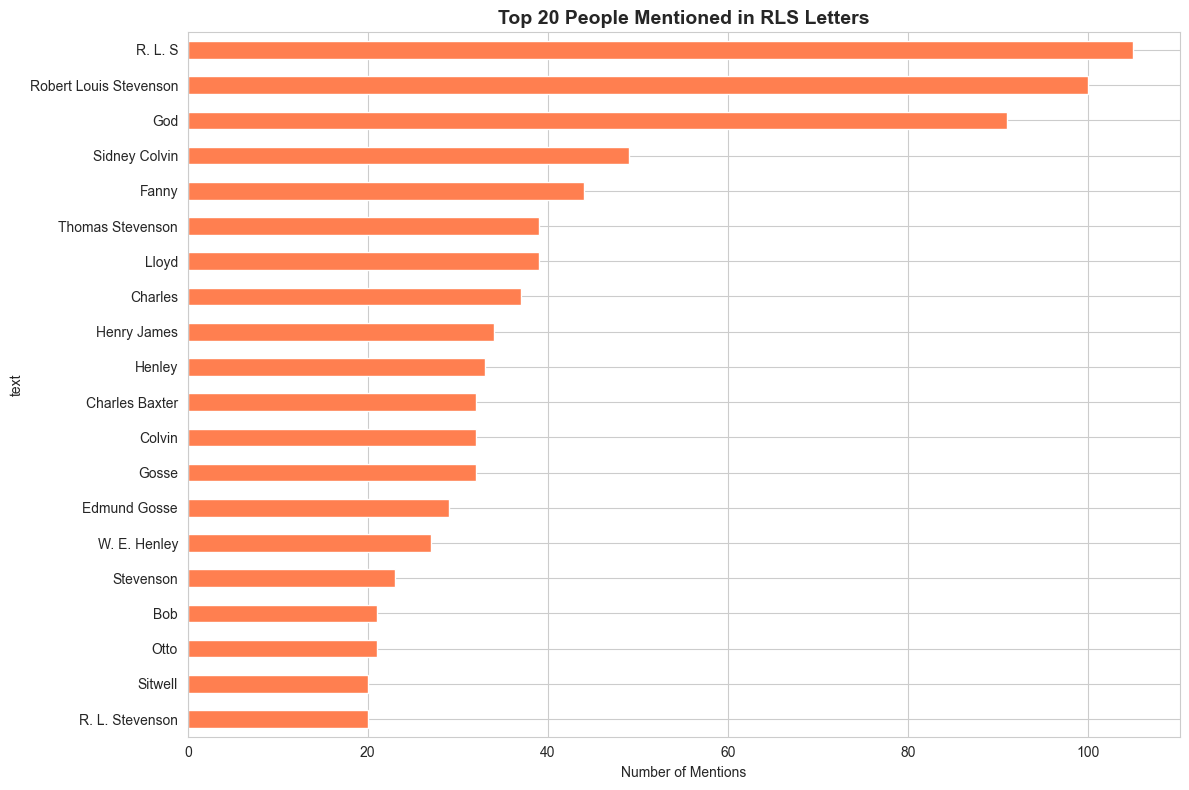

In [101]:
# Most frequently mentioned people
people = entities_df[entities_df['entity_group'] == 'PER']['text'].value_counts().head(20)

print('Top 20 most mentioned people:')
print(people)
print()

# Visualize
plt.figure(figsize=(12, 8))
people.plot(kind='barh', color='coral')
plt.title('Top 20 People Mentioned in RLS Letters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Mentions')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Section 5: Entity Resolution

NER models extract surface forms, *i.e.* the exact text as it appears in the original. This means the same real-world entity can appear under several different names:

| Surface form | Refers to |
|---|---|
| `Robert Louis Stevenson` | the author himself |
| `R. L. Stevenson` | the author himself |
| `R. L. S.` | the author himself |

**Entity resolution** (also called *entity linking* or *coreference resolution*) is the task of mapping these surface forms to a single canonical identifier. Here we'll do it with a hand-crafted dictionary — a practical first step when the domain is well understood.

In [102]:
# A dictionary mapping known surface forms to a canonical name.
# Keys are lowercase for case-insensitive matching.
ENTITY_ALIASES = {
    'r. l. s.': 'Robert Louis Stevenson',
    'r.l.s.': 'Robert Louis Stevenson',
    'r. l. stevenson': 'Robert Louis Stevenson',
    'r.l. stevenson': 'Robert Louis Stevenson',
    'r. l stevenson': 'Robert Louis Stevenson',
    'louis stevenson': 'Robert Louis Stevenson',
    'r. l. s': 'Robert Louis Stevenson',
    'stevenson': 'Robert Louis Stevenson',
}


def resolve_entity(name: str) -> str:
    """Return the canonical name for a surface form, or the original if unknown."""
    return ENTITY_ALIASES.get(name.strip().lower(), name)


# Show the effect on the three RLS surface forms
examples = ['R. L. S.', 'Robert Louis Stevenson', 'R. L. Stevenson']
print('Entity resolution examples:')
for name in examples:
    print(f'  {name!r:<30} -> {resolve_entity(name)!r}')


Entity resolution examples:
  'R. L. S.'                     -> 'Robert Louis Stevenson'
  'Robert Louis Stevenson'       -> 'Robert Louis Stevenson'
  'R. L. Stevenson'              -> 'Robert Louis Stevenson'


In [103]:
# Check how often each surface form appears in the corpus
rls_forms = [*list(ENTITY_ALIASES.keys()), 'robert louis stevenson']
mask = entities_df['text'].str.lower().isin(rls_forms)
print('\nOccurrences of RLS surface forms before resolution:')
print(entities_df[mask]['text'].value_counts().to_string())



Occurrences of RLS surface forms before resolution:
text
R. L. S                   106
Robert Louis Stevenson    100
Stevenson                  26
R. L. Stevenson            20
R. L. S.                   13
Louis Stevenson             1


In [104]:
# Apply resolution to the full DataFrame
entities_df['text'] = entities_df['text'].apply(resolve_entity)

resolved_count = (entities_df['text'] != entities_df['text']).sum()
print(f'\nResolved {resolved_count} entity mentions across the corpus.')
print('\nTop 10 people after resolution:')
print(entities_df[entities_df['entity_group'] == 'PER']['text'].value_counts().head(10).to_string())



Resolved 0 entity mentions across the corpus.

Top 10 people after resolution:
text
Robert Louis Stevenson    262
God                        91
Sidney Colvin              49
Fanny                      44
Thomas Stevenson           39
Lloyd                      39
Charles                    37
Henry James                34
Henley                     33
Charles Baxter             32


## Section 6: Visualization - Network Analysis

Let's create a network graph showing relationships between people mentioned in the letters.

In [105]:
# Get people mentioned in each letter
people_df = entities_df[entities_df['entity_group'] == 'PER'].copy()

# Group by letter
people_by_letter = people_df.groupby('file_name')['text'].apply(list).to_dict()

# Create edges: two people are connected if they appear in the same letter
edges = []
for _, people in people_by_letter.items():
    # Get unique people in this letter
    unique_people = list(set(people))
    # Create edges for all pairs
    if len(unique_people) >= 2:
        for person1, person2 in combinations(unique_people, 2):
            edges.append((person1, person2))

print(f'Created {len(edges)} co-occurrence edges')


Created 8347 co-occurrence edges


In [106]:
# Build network graph
G = nx.Graph()
G.add_edges_from(edges)

print(f'Network has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges')

# Keep only the largest connected component for visualization
largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()

print(f'Largest connected component: {G_main.number_of_nodes()} nodes, {G_main.number_of_edges()} edges')


Network has 1187 nodes and 7360 edges
Largest connected component: 1171 nodes, 7342 edges


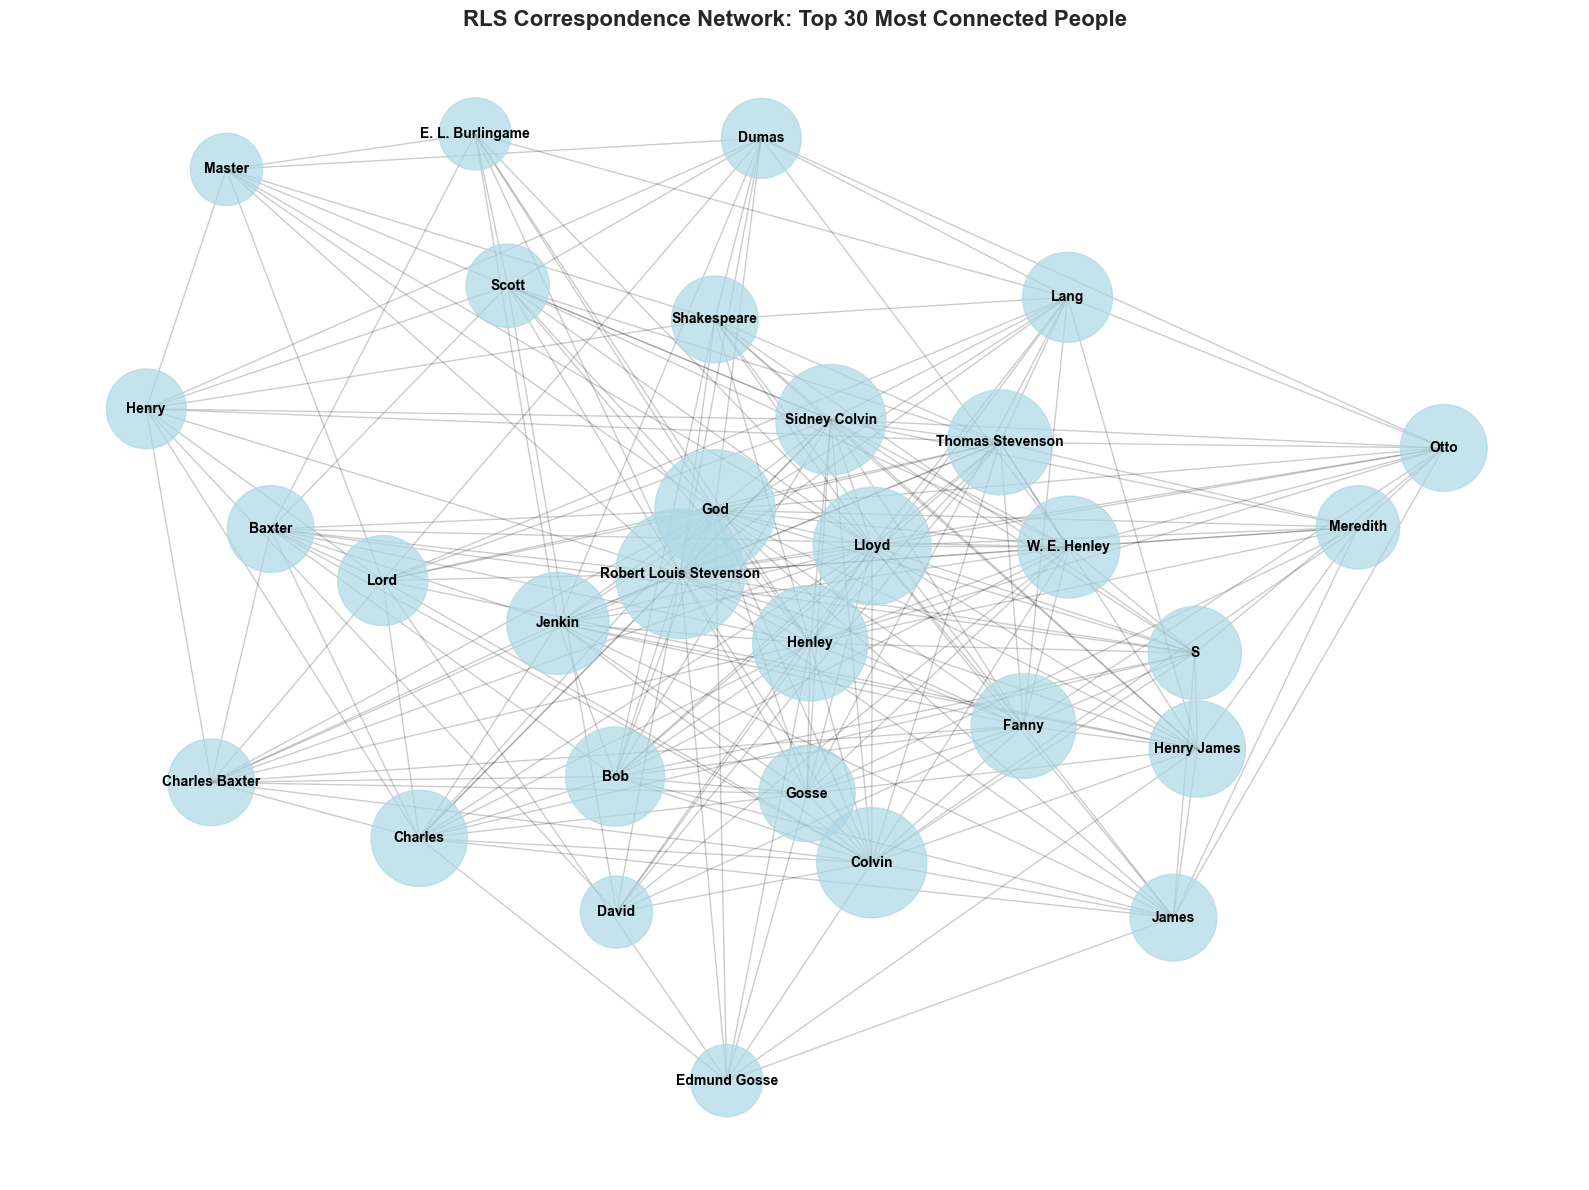

In [107]:
# Filter to top 30 most connected people for clearer visualization
degree_dict = dict(G_main.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:30]
G_viz = G_main.subgraph(top_nodes).copy()

# Visualize
plt.figure(figsize=(16, 12))

# Use spring layout
pos = nx.spring_layout(G_viz, k=0.5, iterations=50, seed=42)

# Node sizes based on degree
node_sizes = [300 * G_viz.degree(node) for node in G_viz.nodes()]

# Draw
nx.draw_networkx_nodes(G_viz, pos, node_size=node_sizes, node_color='lightblue', alpha=0.7)
nx.draw_networkx_edges(G_viz, pos, alpha=0.2)
nx.draw_networkx_labels(G_viz, pos, font_size=10, font_weight='bold')

plt.title('RLS Correspondence Network: Top 30 Most Connected People', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


In [108]:
# Identify central figures
centrality = nx.degree_centrality(G_viz)
top_central = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 most central people in RLS's network:")
for person, score in top_central:
    print(f'  {person:<30} | Centrality: {score:.3f}')


Top 10 most central people in RLS's network:
  Robert Louis Stevenson         | Centrality: 1.000
  God                            | Centrality: 0.862
  Lloyd                          | Centrality: 0.828
  Henley                         | Centrality: 0.793
  Sidney Colvin                  | Centrality: 0.724
  Colvin                         | Centrality: 0.724
  Fanny                          | Centrality: 0.655
  Thomas Stevenson               | Centrality: 0.655
  W. E. Henley                   | Centrality: 0.621
  Jenkin                         | Centrality: 0.621


## Section 7: Timeline Analysis

Track mentions of key people over time.

In [109]:
# Focus on people who were actually correspondents
key_people = ['Colvin', 'Gosse', 'Henley', 'Baxter', 'James', 'Stevenson']

# Filter entities
timeline_df = people_df[people_df['text'].str.contains('|'.join(key_people), case=False)].copy()

# Convert year to numeric
timeline_df['year_num'] = pd.to_numeric(timeline_df['year'], errors='coerce')
timeline_df = timeline_df.dropna(subset=['year_num'])

# Count mentions per person per year
timeline_counts = timeline_df.groupby(['year_num', 'text']).size().reset_index(name='count')

timeline_counts.head()


,year_num,text,count
0,1863.0,R. Stevenson,1
1,1866.0,R. Stevenson,1
2,1868.0,Thomas Stevenson Pulteney,1
3,1868.0,Thomas Stevenson Wick,3
4,1872.0,Baxter,3


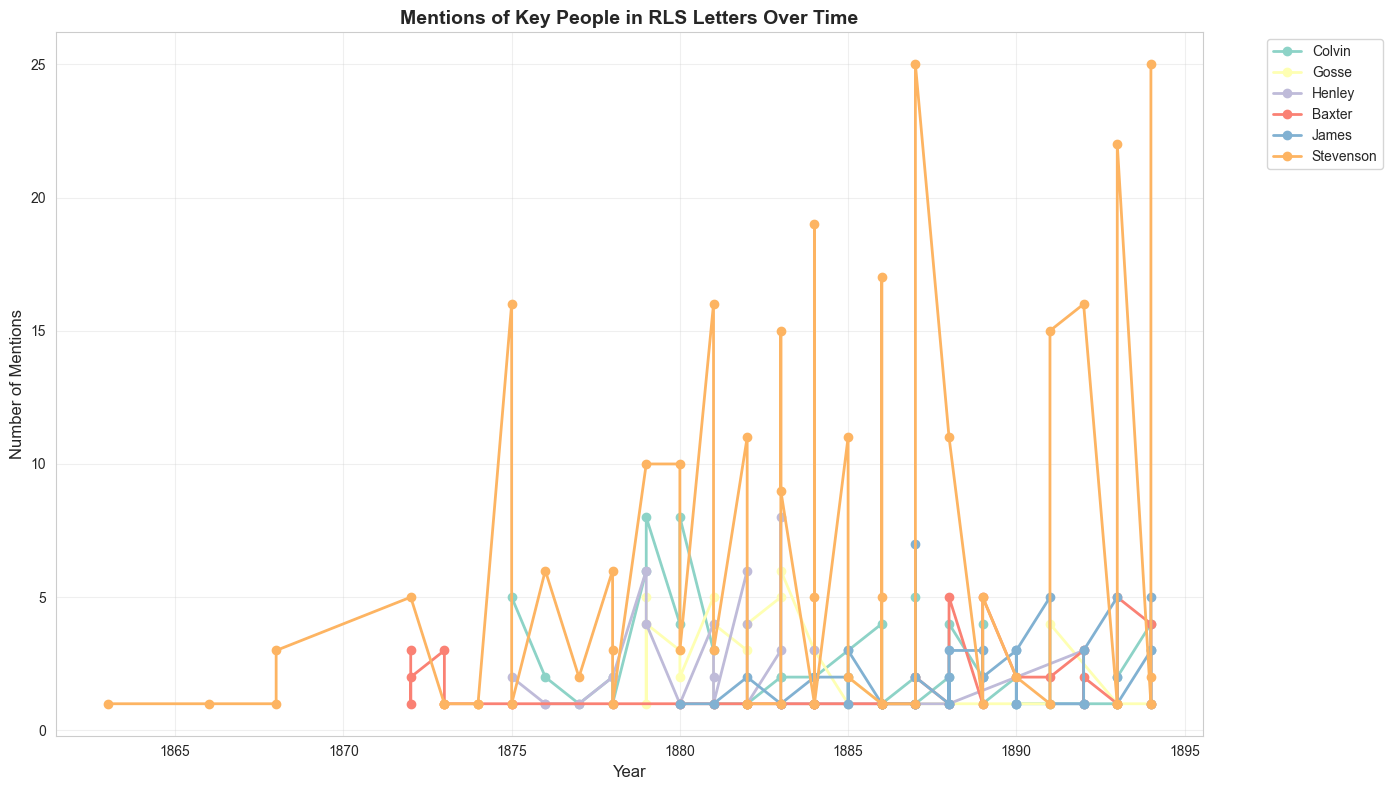

In [110]:
# Plot timeline
plt.figure(figsize=(14, 8))

for person in key_people:
    person_data = timeline_counts[timeline_counts['text'].str.contains(person, case=False)]
    if len(person_data) > 0:
        plt.plot(person_data['year_num'], person_data['count'], marker='o', label=person, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Mentions', fontsize=12)
plt.title('Mentions of Key People in RLS Letters Over Time', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)  # noqa: FBT003
plt.tight_layout()
plt.show()


## Section 8: Evaluation with Manual Annotations

How well does the model actually perform? To find out, we need **ground truth**, *i.e.* a set of letters annotated by humans, so we can compare the model's output against it.

### Workflow

1. The cells below will print a selection of letters.
2. Workshop participants read each letter and record every named entity they spot in a shared Google Sheet.
3. Once the sheet is filled in, we load it here, compute precision, recall, and F1 per entity type, and visualize the results.

### Google Sheet format

| `file_name` | `entity_text` | `entity_type` |
|---|---|---|
| wikisource_vol1_ch3_letter14.txt | Sidney Colvin | PER |
| wikisource_vol1_ch3_letter14.txt | Edinburgh | LOC |
| wikisource_vol1_ch3_letter14.txt | Temple Bar | ORG |

`entity_type` must be one of `PER`, `LOC`, or `ORG`.

When annotation is complete, publish the sheet as CSV: `File → Share → Publish to web → CSV` and paste the URL into the cell below.


In [ ]:
# Select letters for annotation
N_LETTERS = 10
random.seed(42)
sample_files = random.sample(letter_files, N_LETTERS)

print(f'Selected {N_LETTERS} letters for annotation:\n')
for f in sample_files:
    print(f'  {f.name}')


Selected 10 letters for annotation:

  wikisource_vol2_ch11_letter8.txt
  wikisource_vol1_ch3_letter22.txt
  wikisource_vol1_ch1_letter6.txt
  wikisource_vol2_ch12_letter8.txt
  wikisource_vol1_ch5_letter46.txt
  wikisource_vol1_ch5_letter32.txt
  wikisource_vol1_ch5_letter22.txt
  wikisource_vol1_ch3_letter7.txt
  wikisource_vol2_ch12_letter6.txt
  wikisource_vol1_ch3_letter18.txt


In [113]:
SHEET_CSV_URL = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSCY7Fy-vA1dR6OGbvGKNvdKmOwsXhw9VpJFvrATkwtkRjCHsCGH0_CoBcVajyDak0z7Mr7LfPfbdSz/pub?gid=0&single=true&output=csv'

annotations_df = pd.read_csv(SHEET_CSV_URL)

# Normalise column names in case of accidental whitespace
annotations_df.columns = annotations_df.columns.str.strip()
# Normalise capitalization of entity text
annotations_df['entity_text'] = annotations_df['entity_text'].apply(normalize_caps)

print(f'Loaded {len(annotations_df)} annotations from {annotations_df["file_name"].nunique()} letters.')
print('\nAnnotation counts per entity type:')
print(annotations_df['entity_type'].value_counts().to_string())
print('\nSample rows:')
annotations_df.head(10)


Loaded 9 annotations from 1 letters.

Annotation counts per entity type:
entity_type
PER    4
ORG    3
LOC    2

Sample rows:


,file_name,entity_text,entity_type
0,wikisource_vol1_ch3_letter14.txt,Sidney Colvin,PER
1,wikisource_vol1_ch3_letter14.txt,Edinburgh,LOC
2,wikisource_vol1_ch3_letter14.txt,Colvin,PER
3,wikisource_vol1_ch3_letter14.txt,Penzance,LOC
4,wikisource_vol1_ch3_letter14.txt,post-office,ORG
5,wikisource_vol1_ch3_letter14.txt,Cornhill,ORG
6,wikisource_vol1_ch3_letter14.txt,Temple Bar,ORG
7,wikisource_vol1_ch3_letter14.txt,Stephen,PER
8,wikisource_vol1_ch3_letter14.txt,Louis Stevenson,PER


In [114]:
def compute_metrics(gt_set, pred_set):
    """Return precision, recall, and F1 for two sets of entity strings."""
    tp = len(gt_set & pred_set)
    fp = len(pred_set - gt_set)
    fn = len(gt_set - pred_set)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


annotated_files = annotations_df['file_name'].unique()
entity_types = ['PER', 'LOC', 'ORG']

# Map annotation entity_type values to the model's entity_group labels
type_map = {'PER': 'PER', 'LOC': 'LOC', 'ORG': 'ORG'}

rows = []

for etype in entity_types:
    totals = {'tp': 0, 'fp': 0, 'fn': 0}

    for fname in annotated_files:
        # Ground truth: what participants labelled (case-insensitive)
        gt_set = set(
            annotations_df[(annotations_df['file_name'] == fname) & (annotations_df['entity_type'] == etype)][
                'entity_text'
            ]
            .str.strip()
            .str.lower(),
        )

        # Model predictions for the same letter and type
        pred_set = set(
            entities_df[(entities_df['file_name'] == fname) & (entities_df['entity_group'] == type_map[etype])]['text']
            .str.strip()
            .str.lower(),
        )

        m = compute_metrics(gt_set, pred_set)
        for k in ('tp', 'fp', 'fn'):
            totals[k] += m[k]

    # Aggregate across all letters (micro-average)
    precision = totals['tp'] / (totals['tp'] + totals['fp']) if (totals['tp'] + totals['fp']) > 0 else 0.0
    recall = totals['tp'] / (totals['tp'] + totals['fn']) if (totals['tp'] + totals['fn']) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    rows.append({'entity_type': etype, 'precision': precision, 'recall': recall, 'f1': f1, **totals})

metrics_df = pd.DataFrame(rows).set_index('entity_type')

print('Evaluation Results (micro-averaged across annotated letters)\n')
print(metrics_df[['precision', 'recall', 'f1', 'tp', 'fp', 'fn']].to_string())


Evaluation Results (micro-averaged across annotated letters)

             precision    recall   f1  tp  fp  fn
entity_type                                      
PER                0.5  0.500000  0.5   2   2   2
LOC                1.0  1.000000  1.0   2   0   0
ORG                1.0  0.666667  0.8   2   0   1


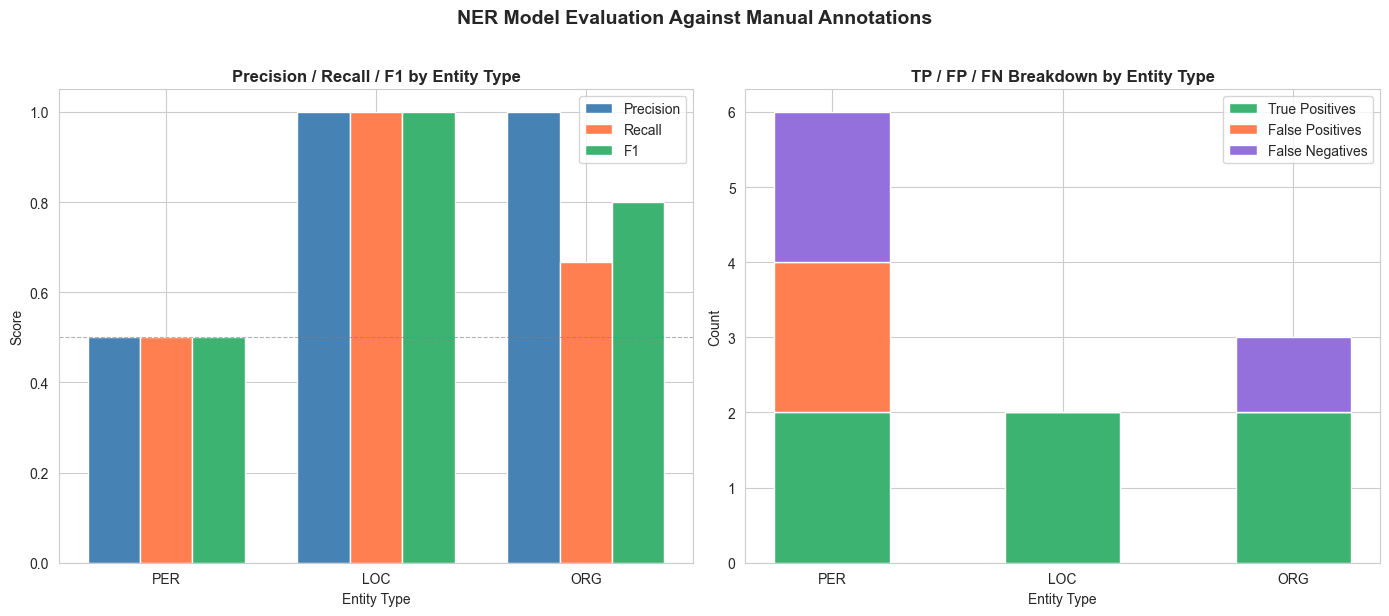

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: grouped bar chart of P / R / F1 per entity type
x = range(len(metrics_df))
width = 0.25
colors = {'precision': 'steelblue', 'recall': 'coral', 'f1': 'mediumseagreen'}

for i, (metric, color) in enumerate(colors.items()):
    axes[0].bar(
        [xi + i * width for xi in x],
        metrics_df[metric],
        width=width,
        label=metric.capitalize(),
        color=color,
    )

axes[0].set_xticks([xi + width for xi in x])
axes[0].set_xticklabels(metrics_df.index)
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('Entity Type')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 by Entity Type', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Right: stacked bar of TP / FP / FN per entity type
bar_width = 0.5
axes[1].bar(metrics_df.index, metrics_df['tp'], bar_width, label='True Positives', color='mediumseagreen')
axes[1].bar(
    metrics_df.index, metrics_df['fp'], bar_width, label='False Positives', color='coral', bottom=metrics_df['tp']
)
axes[1].bar(
    metrics_df.index,
    metrics_df['fn'],
    bar_width,
    label='False Negatives',
    color='mediumpurple',
    bottom=metrics_df['tp'] + metrics_df['fp'],
)

axes[1].set_xlabel('Entity Type')
axes[1].set_ylabel('Count')
axes[1].set_title('TP / FP / FN Breakdown by Entity Type', fontweight='bold')
axes[1].legend()

plt.suptitle('NER Model Evaluation Against Manual Annotations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Section 9: Try an Alternative Model


In [116]:
# Load the NER pipeline
print('Loading NER model... (this may take a minute the first time)')
ner_pipeline = pipeline(
    'ner',
    model='dslim/bert-base-NER',
    aggregation_strategy='simple',  # Combines subword tokens
)
print('Model loaded successfully!')


Loading NER model... (this may take a minute the first time)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [117]:
# Now try the model on our sample letter
entities = ner_pipeline(normalize_caps(sample_text))

print(f'Found {len(entities)} entities in the sample letter:\n')
for entity in entities:
    print(f'{entity["word"]:<30} | {entity["entity_group"]:<6} | {entity["score"]:.3f}')

Found 15 entities in the sample letter:

Sidney Colvin                  | PER    | 0.994
Edinburgh                      | LOC    | 0.999
Col                            | PER    | 0.978
Penzance                       | LOC    | 0.992
Co                             | LOC    | 0.711
##rn                           | LOC    | 0.468
##hill                         | ORG    | 0.642
Temple Bar                     | ORG    | 0.957
Villon                         | MISC   | 0.771
The Sire de Maletroit ' s Mousetrap | MISC   | 0.816
Villon                         | MISC   | 0.808
Stephen                        | PER    | 0.998
Idlers                         | MISC   | 0.537
Stephen                        | PER    | 0.997
Louis Stevenson                | PER    | 0.953
